<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 4. Mejorar la Generalización en modelos</font></h1>

<h1><font color="#113D68" size=4>2. Funciones de activación</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Modelo para Clasificación Binaria](#section1)
* [2. ¿Por qué funciones de activación no lineales?](#section2)
* [3. El Efecto de las Funciones de Activación](#section3)
    * [3.1. ReLU](#section31)
    * [3.2. Sigmoi](#section32)
    * [3.3. Tanh](#section33)
    * [3.4. Variantes de ReLU](#section34)
* [4. Consideraciones finales](#section4)


---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

La función de activación es el “ingrediente mágico” que permite a una red neuronal aproximar una amplia variedad de funciones no lineales. En PyTorch, hay muchas funciones de activación disponibles para su uso en modelos de deep learning. En este capítulo, veremos cómo la elección de estas funciones puede afectar el rendimiento del modelo. Específicamente, abordaremos los siguientes temas:

- Cuáles son las funciones de activación comunes
- La naturaleza de las funciones de activación
- Cómo las diferentes funciones de activación impactan la tasa de aprendizaje
- Cómo la selección de la función de activación puede resolver el problema del gradiente que se desvanece

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
[PyTorch tutorials.](https://pytorch.org/tutorials/)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch API [`torch.nn`.](https://pytorch.org/docs/stable/nn.html)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch API [`torch.optim`.](https://pytorch.org/docs/stable/optim.html)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Modelo para Clasificación Binaria</font>

- Utilizaremos la función `make_circles()` de scikit-learn para crear un conjunto de datos sintético. 

- Este dataset tiene dos características: las coordenadas x e y de los puntos. 

- Cada punto pertenece a una de las dos clases. 

Podemos generar 1000 puntos de datos y visualizarlos de la siguiente manera:

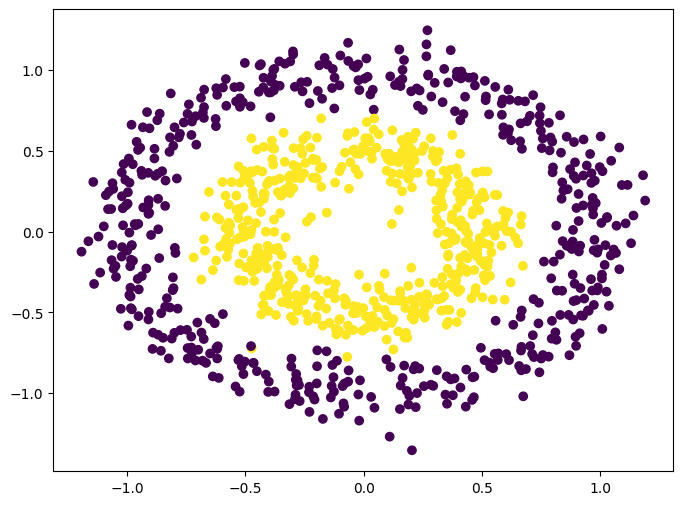

In [1]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import torch

X, y = make_circles(n_samples=1000, factor=0.5, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

Este conjunto de datos es especial porque es simple, pero no linealmente separable: no es posible encontrar una línea recta que separe las dos clases. El reto está en cómo una red neuronal puede descubrir que hay una frontera circular entre las clases.

Ahora, crearemos un modelo de deep learning para resolver este problema. Para simplificar las cosas, no realizaremos validación cruzada. Es posible que la red neuronal se ajuste demasiado a los datos (overfitting), pero eso no afectará nuestra discusión. El modelo tiene 4 capas ocultas y la capa de salida entrega un valor sigmoidal (entre 0 y 1) para la clasificación binaria. El modelo acepta un parámetro en su constructor para especificar qué función de activación utilizar en las capas ocultas. El bucle de entrenamiento se implementa en una función, ya que lo ejecutaremos varias veces.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class Model(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.layer0 = nn.Linear(2, 5)
        self.act0 = activation()
        self.layer1 = nn.Linear(5, 5)
        self.act1 = activation()
        self.layer2 = nn.Linear(5, 5)
        self.act2 = activation()
        self.layer3 = nn.Linear(5, 5)
        self.act3 = activation()
        self.layer4 = nn.Linear(5, 1)  # salida
        self.act4 = nn.Sigmoid()  # binaria: siempre sigmoide al final

    def forward(self, x):
        x = self.act0(self.layer0(x))
        x = self.act1(self.layer1(x))
        x = self.act2(self.layer2(x))
        x = self.act3(self.layer3(x))
        x = self.act4(self.layer4(x))
        return x

def train_loop(model, X, y, n_epochs=300, batch_size=32):
    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    batch_start = torch.arange(0, len(X), batch_size)

    bce_hist = []
    acc_hist = []

    for epoch in range(n_epochs):
        model.train()
        for start in batch_start:
            X_batch = X[start:start+batch_size]
            y_batch = y[start:start+batch_size]
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        model.eval()

        with torch.no_grad():
            y_pred = model(X)
            bce = float(loss_fn(y_pred, y))
            acc = float((y_pred.round() == y).float().mean())
        bce_hist.append(bce)
        acc_hist.append(acc)

        if (epoch+1) % 10 == 0:
            print("Antes de la época %d: BCE=%.4f, Accuracy=%.2f%%" % (epoch+1, bce, acc*100))
    return bce_hist, acc_hist

- Al final de cada época en la función de entrenamiento, evalúas el modelo con todo el conjunto de datos. 

- El resultado de la evaluación se devuelve cuando finaliza el entrenamiento. 

- A continuación, creas un modelo, lo entrenas y trazas el historial de entrenamiento. 

- La función de activación que utilizas es `ReLU` (Rectified Linear Unit), que es la función de activación más común en la actualidad:

Antes de la época 10: BCE=0.6170, Accuracy=83.40%


Antes de la época 20: BCE=0.0714, Accuracy=99.10%


Antes de la época 30: BCE=0.0284, Accuracy=99.50%


Antes de la época 40: BCE=0.0202, Accuracy=99.50%


Antes de la época 50: BCE=0.0168, Accuracy=99.50%


...

Antes de la época 260: BCE=0.0087, Accuracy=99.80%


Antes de la época 270: BCE=0.0087, Accuracy=99.80%


Antes de la época 280: BCE=0.0086, Accuracy=99.80%


Antes de la época 290: BCE=0.0087, Accuracy=99.80%


Antes de la época 300: BCE=0.0085, Accuracy=99.80%


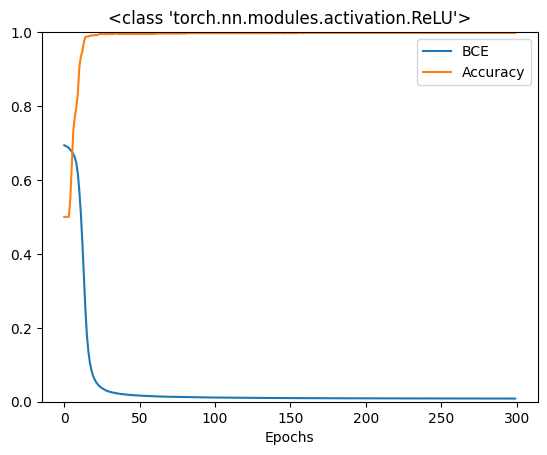

In [3]:
activation = nn.ReLU
model = Model(activation=activation)
bce_hist, acc_hist = train_loop(model, X, y)
plt.plot(bce_hist, label="BCE")
plt.plot(acc_hist, label="Accuracy")
plt.xlabel("Epochs")
plt.ylim(0, 1)
plt.title(str(activation))
plt.legend()
plt.show()

- Después de 300 épocas, el modelo con la función de activación **ReLU** logra una precisión del 90%. 

- Históricamente, las funciones **sigmoide** y **tangente hiperbólica** fueron muy comunes en la literatura de redes neuronales. 

Veamos una comparación de estas tres funciones de activación utilizando `matplotlib`:

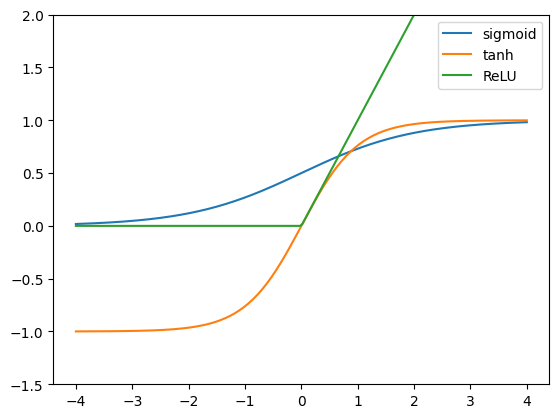

In [4]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

x = torch.linspace(-4, 4, 200)
relu = nn.ReLU()(x)
tanh = nn.Tanh()(x)
sigmoid = nn.Sigmoid()(x)

plt.plot(x, sigmoid, label="sigmoid")
plt.plot(x, tanh, label="tanh")
plt.plot(x, relu, label="ReLU")
plt.ylim(-1.5, 2)
plt.legend()
plt.show()

### Descripción de las Funciones de Activación

- **ReLU** (Rectified Linear Unit): Se llama función lineal rectificada porque es una función lineal $y = x$ en la región positiva de $x$, pero permanece en cero si $x$ es negativo. Matemáticamente, se define como $y = \max(0, x)$.

- **Tangente Hiperbólica** ($y = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$): Va suavemente de -1 a +1.

- **Sigmoide** ($y = \sigma(x) = \frac{1}{1 + e^{-x}}$): Va de 0 a +1.

Si intentas derivar estas funciones, encontrarás que:

- ReLU es la más sencilla: su gradiente es 1 en la región positiva y 0 en otros casos. 
- TanH tiene una pendiente más pronunciada, por lo que su gradiente es mayor que el de la función sigmoide.

Todas estas funciones son monótonamente crecientes, lo que significa que sus gradientes nunca son negativos, una de las propiedades necesarias para una función de activación adecuada para redes neuronales.

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. ¿Por qué funciones de activación no lineales?</font>

- Importancia de las funciones de activación no lineales:
  - Permiten representar funciones más complejas

  - Evitan que múltiples capas lineales se reduzcan a una sola capa lineal

- Problema con capas lineales:
  - Usar múltiples capas lineales equivale a usar una sola capa lineal

  - Limita la capacidad de la red para modelar relaciones complejas

- Conclusión:
  - Las funciones de activación no lineales son cruciales para la efectividad de las redes neuronales profundas
  
  - Sin ellas, las redes neuronales perderían su capacidad de modelar relaciones complejas y no lineales

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. El Efecto de las Funciones de Activación</font>

- Modificación del bucle de entrenamiento:
  - Objetivo: Capturar más información sobre los gradientes

- Estructura del modelo:
  - Cuatro capas ocultas
  
  - Una capa de salida

- Proceso de retropropagación:
  - Calcula el gradiente de los pesos en cada capa

  - Optimizador actualiza los pesos basándose en estos gradientes

- Importancia de observar los cambios en los gradientes durante el entrenamiento

- Modificación del bucle para recopilar datos:
  - Captura el valor absoluto medio del gradiente en cada capa

  - Se realiza en cada paso de entrenamiento

Esta modificación permite un análisis más detallado del comportamiento de los gradientes durante el entrenamiento.

In [5]:
import numpy as np

def train_loop(model, X, y, n_epochs=300, batch_size=32):
    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    batch_start = torch.arange(0, len(X), batch_size)

    bce_hist = []
    acc_hist = []
    grad_hist = [[], [], [], [], []]  # una lista por capa

    for epoch in range(n_epochs):
        model.train()
        layer_grad = [[], [], [], [], []]
        for start in batch_start:
            X_batch = X[start:start+batch_size]
            y_batch = y[start:start+batch_size]
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # media del valor absoluto del gradiente de los pesos de cada capa
            layers = [model.layer0, model.layer1, model.layer2, model.layer3, model.layer4]
            for n, layer in enumerate(layers):
                layer_grad[n].append(float(layer.weight.grad.abs().mean()))

        model.eval()
        with torch.no_grad():
            y_pred = model(X)
            bce = float(loss_fn(y_pred, y))
            acc = float((y_pred.round() == y).float().mean())
        bce_hist.append(bce)
        acc_hist.append(acc)
        for n, grads in enumerate(layer_grad):
            grad_hist[n].append(np.mean(grads))  # promedio de la época

        if epoch % 10 == 9:
            print("Época %d: BCE=%.4f, Accuracy=%.2f%%" % (epoch, bce, acc*100))
    return bce_hist, acc_hist, grad_hist

- Acceso a los gradientes:
  - Disponibles después del proceso de retropropagación

  - Accesibles mediante `model.layer0.weight.grad`

- Procesamiento de gradientes:
  1. Tomar valor absoluto de cada elemento
  
  2. Calcular la media sobre todos los elementos

- Características de los valores de gradientes:
  - Dependientes del lote

  - Pueden ser ruidosos

- Resumen de gradientes:
  - Se realiza al final de cada época

  - Se calcula el valor absoluto medio

- Estructura de la red neuronal:
  - Cinco capas en total (capas ocultas + capa de salida)

- Visualización:
  - Patrón de gradientes de cada capa a lo largo de las épocas

- Proceso de ejecución y visualización:
  1. Ejecutar el bucle de entrenamiento

  2. Trazar entropía cruzada y accuracy

  3. Trazar valor absoluto medio del gradiente para cada capa

Esta visualización permite analizar la evolución de los gradientes en relación con el rendimiento del modelo.

<a id="section31"></a>
# <font color="#004D7F" size=5>3.1. ReLU</font>

- Observaciones en la gráfica:
  - Aumento del accuracy

  - Disminución de la pérdida de entropía cruzada
  
  - Fluctuación de gradientes en rangos similares para todas las capas

- Comportamiento ideal. Prestar atención especial a las líneas de:
  - Primera capa

  - Última capa

- Interpretación:
  - El comportamiento observado indica un entrenamiento efectivo

  - Gradientes similares en todas las capas sugieren un aprendizaje equilibrado

  - La evolución de accuracy y pérdida muestra mejora del modelo

- Importancia:
  - Ayuda a entender la dinámica del entrenamiento

  - Permite identificar posibles problemas (ej. desvanecimiento de gradientes)

  - Facilita la optimización del proceso de aprendizaje

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [`ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)

Época 9: BCE=0.6271, Accuracy=78.00%


Época 19: BCE=0.1205, Accuracy=99.40%


Época 29: BCE=0.0454, Accuracy=99.40%


Época 39: BCE=0.0298, Accuracy=99.50%


Época 49: BCE=0.0239, Accuracy=99.50%


...

Época 259: BCE=0.0091, Accuracy=99.90%


Época 269: BCE=0.0089, Accuracy=99.90%


Época 279: BCE=0.0088, Accuracy=99.90%


Época 289: BCE=0.0086, Accuracy=99.90%


Época 299: BCE=0.0085, Accuracy=99.90%


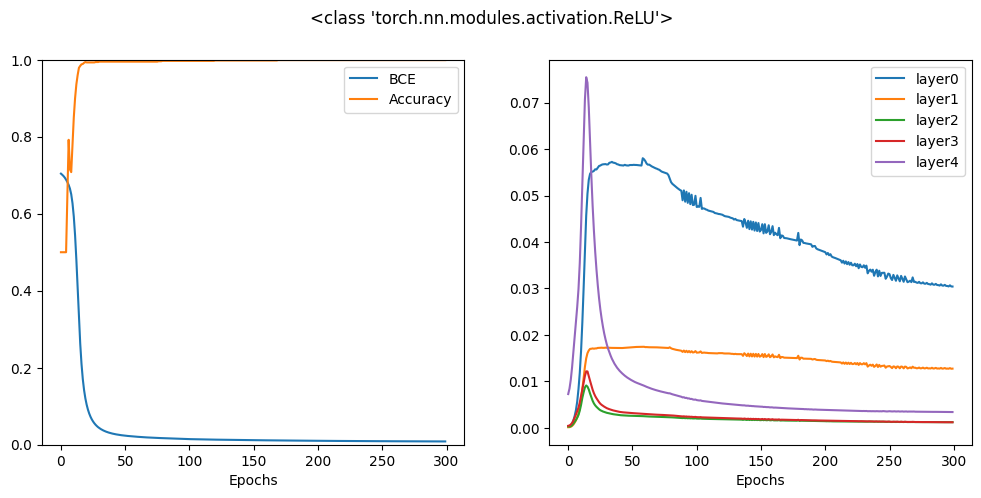

In [6]:
activation = nn.ReLU
model = Model(activation=activation)
bce_hist, acc_hist, grad_hist = train_loop(model, X, y)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(bce_hist, label="BCE")
ax[0].plot(acc_hist, label="Accuracy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylim(0, 1)
for n, grads in enumerate(grad_hist):
    ax[1].plot(grads, label="layer"+str(n))
ax[1].set_xlabel("Epochs")
fig.suptitle(str(activation))
ax[0].legend()
ax[1].legend()
plt.show()

<a id="section32"></a>
# <font color="#004D7F" size=5>3.2. Sigmoid</font>

- Experimento repetido con función de activación sigmoide

- Resultados después de 300 épocas:
  - Significativamente peor que con activación ReLU
  
  - Requiere muchas más épocas para converger

- Observaciones en la gráfica:
  - Gradientes significativos solo en la capa de salida
  
  - Gradientes prácticamente nulos en las capas ocultas

- Problema identificado: Efecto del gradiente que se desvanece

  - Común en redes neuronales con activación sigmoide

- Implicaciones:
  - Aprendizaje lento o estancado en capas profundas

  - Dificultad para ajustar pesos en capas iniciales

  - Menor capacidad de la red para aprender representaciones complejas

- Comparación con ReLU:
  - ReLU no sufre de este problema en la misma medida

  - ReLU permite un aprendizaje más rápido y efectivo

- Conclusión:
  - La elección de la función de activación es crucial para el rendimiento del modelo
  
  - Sigmoide puede ser problemática en redes profundas debido al desvanecimiento del gradiente

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [`Sigmoid`](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html)

Época 9: BCE=0.6931, Accuracy=50.00%


Época 19: BCE=0.6932, Accuracy=50.00%


Época 29: BCE=0.6932, Accuracy=50.00%


Época 39: BCE=0.6932, Accuracy=50.00%


Época 49: BCE=0.6932, Accuracy=50.00%


...

Época 259: BCE=0.0317, Accuracy=99.40%


Época 269: BCE=0.0284, Accuracy=99.40%


Época 279: BCE=0.0259, Accuracy=99.40%


Época 289: BCE=0.0238, Accuracy=99.40%


Época 299: BCE=0.0222, Accuracy=99.40%


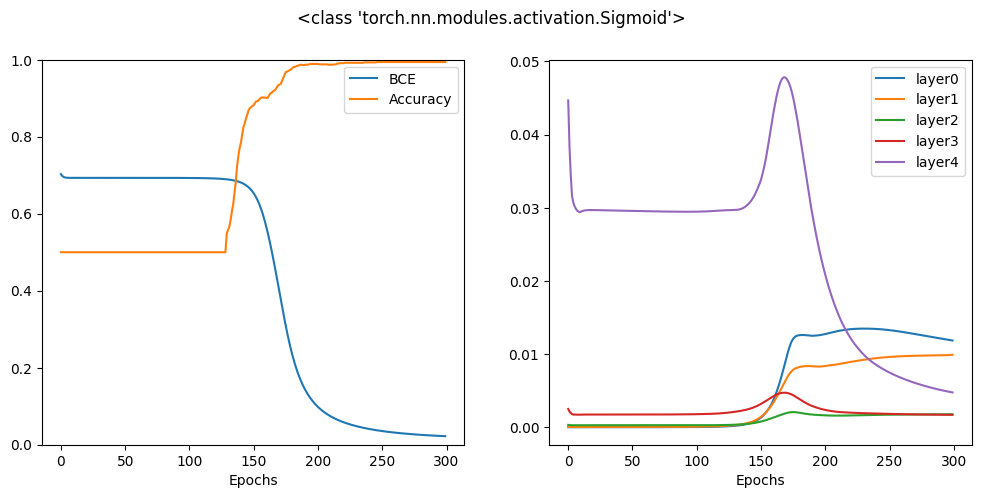

In [7]:
activation = nn.Sigmoid
model = Model(activation=activation)
bce_hist, acc_hist, grad_hist = train_loop(model, X, y)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(bce_hist, label="BCE")
ax[0].plot(acc_hist, label="Accuracy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylim(0, 1)
for n, grads in enumerate(grad_hist):
    ax[1].plot(grads, label="layer"+str(n))
ax[1].set_xlabel("Epochs")
fig.suptitle(str(activation))
ax[0].legend()
ax[1].legend()
plt.show()

<a id="section33"></a>
# <font color="#004D7F" size=5>3.3. Tanh</font>

- Experimento con función de activación tangente hiperbólica (tanh)

- Características de tanh:
  - Forma similar a la sigmoide

  - Curva más pronunciada

- Resultados:
  - Mejor que la activación sigmoide

  - Peor que la activación ReLU

- Observaciones en la gráfica de gradientes:
  - Gradientes significativos en las capas ocultas
  
  - Mejora respecto a sigmoide

- Limitación de tanh:
  - Proceso de retropropagación no muy efectivo hacia la capa de entrada

  - Causa: grandes regiones planas en la función tanh

- Implicaciones:
  - Mejor aprendizaje que sigmoide en capas profundas

  - Todavía presenta dificultades para propagar gradientes a capas iniciales

- Comparación:
  - Superior a sigmoide en rendimiento

  - Inferior a ReLU en eficacia de entrenamiento

- Conclusión:
  - Tanh ofrece una mejora sobre sigmoide para redes profundas
  
  - ReLU sigue siendo más efectiva para el aprendizaje en general

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [`Tanh`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html).

Época 9: BCE=0.6903, Accuracy=56.70%


Época 19: BCE=0.5378, Accuracy=76.80%


Época 29: BCE=0.2180, Accuracy=93.30%


Época 39: BCE=0.0451, Accuracy=99.40%


Época 49: BCE=0.0297, Accuracy=99.40%


...

Época 259: BCE=0.0149, Accuracy=99.60%


Época 269: BCE=0.0149, Accuracy=99.60%


Época 279: BCE=0.0148, Accuracy=99.60%


Época 289: BCE=0.0147, Accuracy=99.60%


Época 299: BCE=0.0146, Accuracy=99.60%


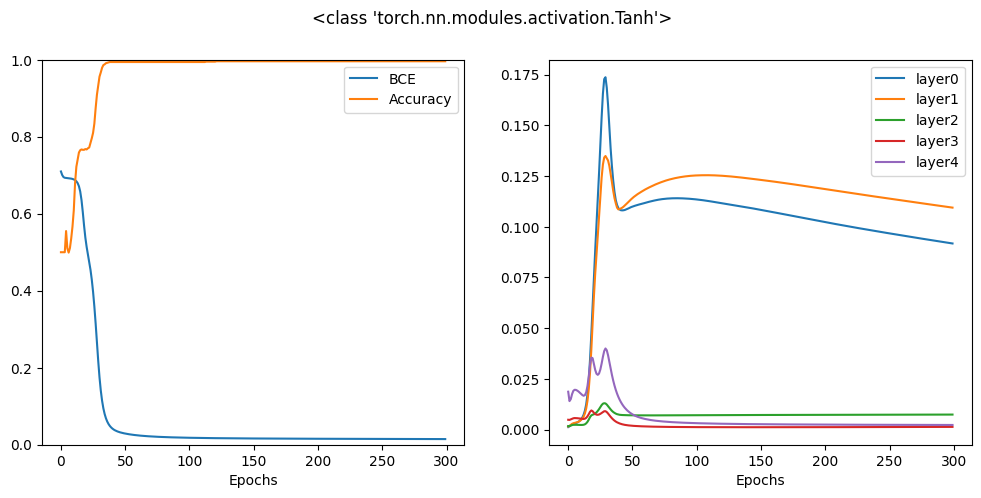

In [8]:
activation = nn.Tanh
model = Model(activation=activation)
bce_hist, acc_hist, grad_hist = train_loop(model, X, y)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(bce_hist, label="BCE")
ax[0].plot(acc_hist, label="Accuracy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylim(0, 1)
for n, grads in enumerate(grad_hist):
    ax[1].plot(grads, label="layer"+str(n))
ax[1].set_xlabel("Epochs")
fig.suptitle(str(activation))
ax[0].legend()
ax[1].legend()
plt.show()

<a id="section34"></a>
# <font color="#004D7F" size=5>3.4. Variantes de ReLU</font>

- ReLU es ampliamente utilizada en la actualidad debido a:
  - Simplicidad
  - Cálculo rápido de su derivada
  - Facilita una convergencia más rápida del modelo

- Ventajas de ReLU:
  - Eficiencia computacional
  - Mejora la velocidad de entrenamiento

- Posibilidad de mejorar el rendimiento de ReLU en ciertos casos

- PyTorch ofrece varias variaciones de ReLU:
  - Diseñadas para abordar limitaciones específicas de ReLU estándar

- Comparación planteada:
  - ReLU estándar
  - Dos variaciones de ReLU

- Objetivo de la comparación:
  - Evaluar el rendimiento relativo de cada variante
  - Identificar posibles mejoras sobre ReLU estándar

- Importancia de entender estas variaciones:
  - Puede llevar a mejoras en el rendimiento del modelo
  - Permite seleccionar la función de activación más adecuada para cada caso


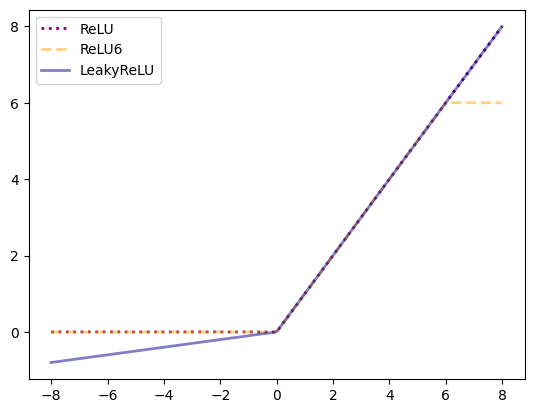

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

x = torch.linspace(-8,8,200)
relu = nn.ReLU()(x)
relu6 = nn.ReLU6()(x)
leaky = nn.LeakyReLU(negative_slope=0.1)(x)

plt.plot(x, relu, c="purple", lw=2, ls=":", label="ReLU")
plt.plot(x, relu6, c="orange", lw=2, ls="--", alpha=0.5, label="ReLU6")
plt.plot(x, leaky, c="darkblue", lw=2, alpha=0.5, label="LeakyReLU")
plt.legend()
plt.show()

### **ReLU6**: 

- Es una variante de ReLU que limita la función a 6.0 si el valor de entrada es mayor que 6.0.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [`ReLU6`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU6.html)

Época 9: BCE=0.6907, Accuracy=50.00%


Época 19: BCE=0.5413, Accuracy=73.80%


Época 29: BCE=0.4420, Accuracy=79.20%


Época 39: BCE=0.3884, Accuracy=82.90%


Época 49: BCE=0.3255, Accuracy=87.10%


...

Época 259: BCE=0.0134, Accuracy=99.40%


Época 269: BCE=0.0133, Accuracy=99.40%


Época 279: BCE=0.0132, Accuracy=99.40%


Época 289: BCE=0.0131, Accuracy=99.40%


Época 299: BCE=0.0130, Accuracy=99.40%


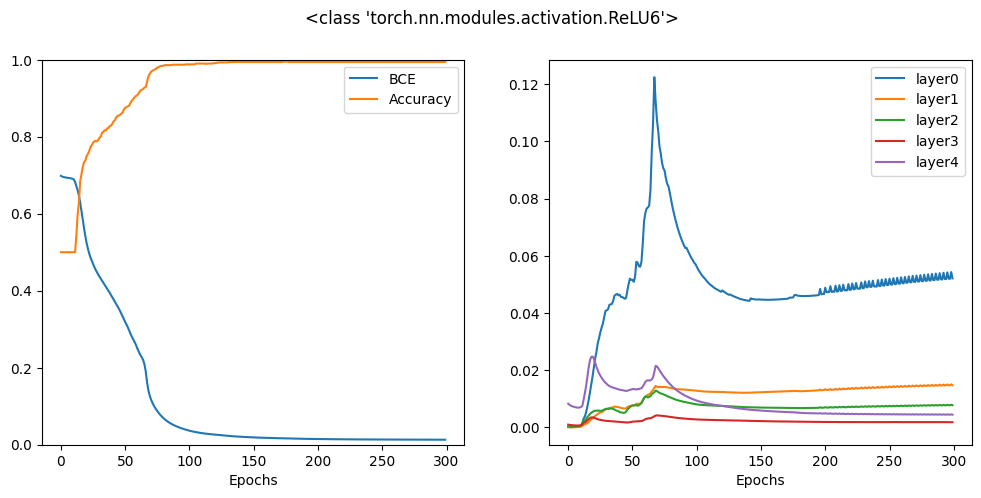

In [10]:
activation = nn.ReLU6
model = Model(activation=activation)
bce_hist, acc_hist, grad_hist = train_loop(model, X, y)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(bce_hist, label="BCE")
ax[0].plot(acc_hist, label="Accuracy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylim(0, 1)
for n, grads in enumerate(grad_hist):
    ax[1].plot(grads, label="layer"+str(n))
ax[1].set_xlabel("Epochs")
fig.suptitle(str(activation))
ax[0].legend()
ax[1].legend()
plt.show()

### **Leaky ReLU**: 

- En lugar de una mitad negativa plana, mantiene una pequeña pendiente positiva en esa región. 

- La lógica detrás de esto es evitar que la activación sea completamente cero para entradas negativas, lo que ayuda a mantener cierta información en los gradientes.

- Después de 300 épocas, todas estas variaciones pueden ofrecer un accuracy similar, pero las curvas de la historia muestran que algunas llegan a una alto accuracy más rápido que otras. 

- Esto se debe a la interacción entre el gradiente de la función de activación y el optimizador.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [`LeakyReLU`](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html)

Época 9: BCE=0.6723, Accuracy=65.00%


Época 19: BCE=0.2127, Accuracy=99.00%


Época 29: BCE=0.0371, Accuracy=99.70%


Época 39: BCE=0.0235, Accuracy=99.70%


Época 49: BCE=0.0193, Accuracy=99.70%


...

Época 259: BCE=0.0096, Accuracy=99.80%


Época 269: BCE=0.0095, Accuracy=99.80%


Época 279: BCE=0.0094, Accuracy=99.80%


Época 289: BCE=0.0093, Accuracy=99.80%


Época 299: BCE=0.0093, Accuracy=99.80%


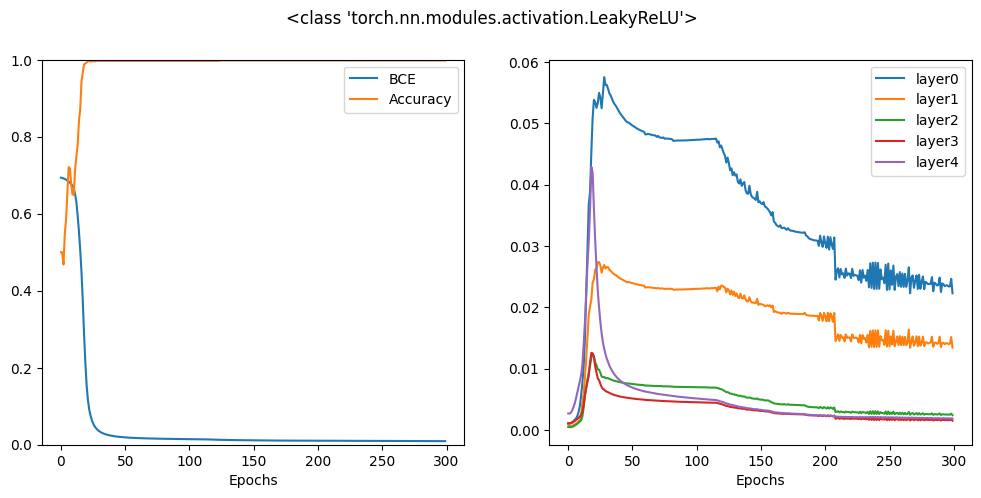

In [11]:
activation = nn.LeakyReLU
model = Model(activation=activation)
bce_hist, acc_hist, grad_hist = train_loop(model, X, y)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(bce_hist, label="BCE")
ax[0].plot(acc_hist, label="Accuracy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylim(0, 1)
for n, grads in enumerate(grad_hist):
    ax[1].plot(grads, label="layer"+str(n))
ax[1].set_xlabel("Epochs")
fig.suptitle(str(activation))
ax[0].legend()
ax[1].legend()
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section4"></a>
# <font color="#004D7F" size=6>4. Consideraciones finales</font>

No existe una regla de oro que diga cuál es la mejor función de activación, pero el diseño de la función ayuda en aspectos clave, como:

- **Retropropagación**: Pasar la métrica de pérdida desde la capa de salida hasta la capa de entrada.

- **Cálculo de gradientes estables**: Mantener una calculación estable del gradiente en condiciones específicas, como el accuracy limitada de punto flotante. Las funciones de activación deben ser robustas ante errores de redondeo.

- **Contraste en las entradas**: Proporcionar suficiente contraste en las entradas para que la retropropagación determine ajustes precisos en los parámetros.

Como vimos, aunque la función sigmoide es una tanh aplanada (ya que $\tanh(x) = 2\sigma(2x) - 1 $), los resultados son bastante diferentes debido a los gradientes que se propagan.

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>